# Intelligent Student Academic Progress Monitoring & Early Risk Prediction System
## Full Course Analysis + Models Notebook

**Dataset:** OULAD — Open University Learning Analytics Dataset  
**Prediction point:** Day 28  
**Target:** `1 = At Risk (Fail or Withdrawn)`, `0 = Not At Risk (Pass or Distinction)`

This notebook is the **course-facing end-to-end analysis**. It combines the analysis workflow and the classification models covered in the course while preserving the project's hardened methodology.

### Methodological guardrails
- Only information available from **Day 0 to Day 28** is used as predictive input.
- `final_result` is used only to construct the target and is **never** used as a predictive feature.
- `id_student` is used only for **group-aware splitting**, never as a feature.
- The canonical split is student-group-aware, so the same student cannot appear in both development and locked evaluation data.
- Course-model comparison below is **development-only 5-fold group-aware CV**.
- The official locked evaluation holdout is **not used to choose among the course models**.
- Extra material (SHAP, fairness, calibration, ANN extension, dashboard) is clearly separated from the core course requirements.


In [1]:
from pathlib import Path
import json
import sys
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore')

# Work whether the notebook is launched from project root or from notebooks/.
HERE = Path.cwd().resolve()
PROJECT_ROOT = HERE if (HERE / 'data' / 'processed' / 'student_risk_day28.csv').exists() else HERE.parent
if not (PROJECT_ROOT / 'data' / 'processed' / 'student_risk_day28.csv').exists():
    raise FileNotFoundError('Open this notebook from the project root or notebooks/ directory.')

sys.path.insert(0, str(PROJECT_ROOT / 'src'))
from split_utils import TARGET, GROUP, DROP_FROM_X, CV_SEED, indices_from_manifest

DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'student_risk_day28.csv'
MANIFEST_PATH = PROJECT_ROOT / 'reports' / 'tuning' / 'locked_split_manifest.csv'
COURSE_REPORT_DIR = PROJECT_ROOT / 'reports' / 'course_models'
COURSE_REPORT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)
print('Project root:', PROJECT_ROOT)


Project root: /mnt/data/course_notebook_work/student_risk_oulad_project


## 1. Problem Definition

The project is a **supervised binary classification** problem. The goal is to identify students who may be academically at risk early enough to support intervention.

The prediction is made at **Day 28**, before the final academic outcome is known. Therefore regression, clustering, reinforcement learning, and CNNs are not the primary tools for this target. They are valuable course topics, but they answer different problem types.

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Rows: {len(df):,}')
print(f'Unique students: {df[GROUP].nunique():,}')
print(f'Columns: {df.shape[1]}')
print(f'At-risk rate: {df[TARGET].mean():.2%}')

display(df.head(3))


Rows: 27,515
Unique students: 24,826
Columns: 61
At-risk rate: 44.11%


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,date_registration,module_presentation_length,target_at_risk,final_result,total_clicks_28d,active_days_28d,unique_sites_28d,unique_activity_types_28d,last_activity_day_28d,avg_clicks_per_active_day_28d,days_since_last_activity_28d,clicks_week1_28d,clicks_week2_28d,clicks_week3_28d,clicks_week4_28d,weekly_click_slope_28d,click_change_week4_vs_week1,clicks_last7d,active_days_last7d,vle_clicks_dataplus_28d,vle_clicks_dualpane_28d,vle_clicks_externalquiz_28d,vle_clicks_forumng_28d,vle_clicks_glossary_28d,vle_clicks_homepage_28d,vle_clicks_htmlactivity_28d,vle_clicks_oucollaborate_28d,vle_clicks_oucontent_28d,vle_clicks_ouelluminate_28d,vle_clicks_ouwiki_28d,vle_clicks_page_28d,vle_clicks_questionnaire_28d,vle_clicks_quiz_28d,vle_clicks_resource_28d,vle_clicks_sharedsubpage_28d,vle_clicks_subpage_28d,vle_clicks_url_28d,assessments_submitted_28d,assessment_mean_score_28d,assessment_min_score_28d,assessment_max_score_28d,late_submissions_28d,banked_submissions_28d,assessment_weight_completed_28d,weighted_assessment_score_28d,assessments_due_28d,assessment_weight_due_28d,assessments_missed_28d,assessment_completion_rate_28d,has_early_assessment_28d
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,-159.0,268,0,Pass,303.0,7.0,24.0,6.0,18.0,43.285714,10.0,183.0,20.0,100.0,0.0,-46.9,-183.0,0.0,0.0,0.0,0.0,0.0,53.0,0.0,35.0,0.0,0.0,195.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,10.0,1.0,1.0,78.0,78.0,78.0,0.0,0.0,10.0,78.0,1.0,10.0,0.0,1.0,1
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,-53.0,268,0,Pass,403.0,12.0,25.0,5.0,28.0,33.583333,0.0,175.0,66.0,37.0,125.0,-17.9,-50.0,125.0,4.0,0.0,0.0,0.0,136.0,0.0,86.0,0.0,0.0,122.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36.0,23.0,1.0,70.0,70.0,70.0,1.0,0.0,10.0,70.0,1.0,10.0,0.0,1.0,1
2,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,-52.0,268,0,Pass,325.0,17.0,22.0,6.0,28.0,19.117647,0.0,22.0,154.0,108.0,41.0,1.1,19.0,41.0,5.0,0.0,0.0,0.0,102.0,0.0,65.0,0.0,0.0,110.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,33.0,14.0,1.0,72.0,72.0,72.0,0.0,0.0,10.0,72.0,1.0,10.0,0.0,1.0,1


## 2. Target Definition and Leakage Removal

The observed final outcome is mapped to the binary target:

- **At Risk = 1:** `Fail` or `Withdrawn`
- **Not At Risk = 0:** `Pass` or `Distinction`

`final_result` is therefore a **target source**, not a feature. The student ID is also excluded from X and used only as the grouping key.

In [3]:
target_check = pd.crosstab(df['final_result'], df[TARGET], margins=True)
display(target_check)

X_all = df.drop(columns=DROP_FROM_X)
y_all = df[TARGET].astype(int)
groups_all = df[GROUP]

for forbidden in [TARGET, GROUP, 'final_result']:
    assert forbidden not in X_all.columns

# Day-28 integrity checks available directly from the engineered table.
assert df['last_activity_day_28d'].dropna().le(28).all()
assert df['active_days_28d'].ge(0).all()
assert df['clicks_last7d'].ge(0).all()

print('Predictive columns before encoding:', X_all.shape[1])
print('Leakage guard: target, student ID, and final_result are absent from X.')
print('Day-28 activity guard: no last_activity_day_28d value exceeds Day 28.')


target_at_risk,0,1,All
final_result,,,
Distinction,3023,0,3023
Fail,0,7032,7032
Pass,12355,0,12355
Withdrawn,0,5105,5105
All,15378,12137,27515


Predictive columns before encoding: 58
Leakage guard: target, student ID, and final_result are absent from X.
Day-28 activity guard: no last_activity_day_28d value exceeds Day 28.


## 3. Canonical Student-Group-Aware Split

A normal random row split could put different enrollments of the **same student** on both sides. That would leak student identity across evaluation boundaries.

The project therefore uses a persisted canonical split by `id_student`. All model comparison in this notebook uses only the **development** portion.

In [4]:
manifest = pd.read_csv(MANIFEST_PATH)
dev_idx, holdout_idx = indices_from_manifest(manifest)

dev = df.iloc[dev_idx].copy()
holdout = df.iloc[holdout_idx].copy()

assert set(dev[GROUP]).isdisjoint(set(holdout[GROUP]))

split_summary = pd.DataFrame({
    'Split': ['Development', 'Locked evaluation'],
    'Rows': [len(dev), len(holdout)],
    'Unique students': [dev[GROUP].nunique(), holdout[GROUP].nunique()],
    'At-risk rate': [dev[TARGET].mean(), holdout[TARGET].mean()],
})
display(split_summary.style.format({'Rows':'{:,}','Unique students':'{:,}','At-risk rate':'{:.2%}'}))
print('Student overlap:', len(set(dev[GROUP]) & set(holdout[GROUP])))


,Split,Rows,Unique students,At-risk rate
0,Development,"22,011","19,851",44.11%
1,Locked evaluation,"5,504","4,975",44.11%


Student overlap: 0


## 4. Exploratory Data Analysis (Development Data Only)

To avoid repeatedly looking at the locked evaluation cohort during development, the EDA cells below use the development split.

,count
target_at_risk,
Not At Risk,12302
At Risk,9709


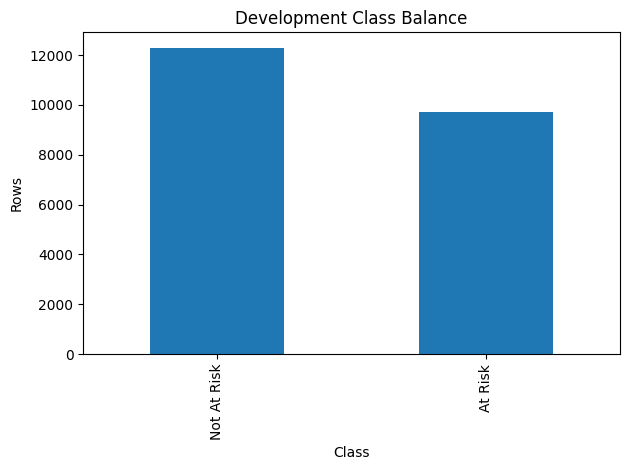

In [5]:
dev_balance = dev[TARGET].value_counts().sort_index().rename(index={0:'Not At Risk',1:'At Risk'})
display(dev_balance.to_frame('count'))

ax = dev_balance.plot(kind='bar', title='Development Class Balance')
ax.set_xlabel('Class')
ax.set_ylabel('Rows')
plt.tight_layout()
plt.show()


In [6]:
missing = dev[X_all.columns].isna().mean().sort_values(ascending=False)
missing = missing[missing > 0].head(15)
print('Top missingness rates in development features:')
display((missing * 100).rename('missing_%').to_frame().round(2))


Top missingness rates in development features:


,missing_%
weighted_assessment_score_28d,33.12
assessment_max_score_28d,27.09
assessment_mean_score_28d,27.09
assessment_min_score_28d,27.09
assessment_completion_rate_28d,18.21
last_activity_day_28d,4.34
imd_band,3.75


In [7]:
engagement_cols = [
    'total_clicks_28d','active_days_28d','days_since_last_activity_28d',
    'clicks_last7d','assessments_submitted_28d','assessments_missed_28d',
    'assessment_completion_rate_28d','assessment_mean_score_28d'
]
comparison = dev.groupby(TARGET)[engagement_cols].mean().T
comparison.columns = ['Not At Risk mean','At Risk mean']
display(comparison.round(3))


,Not At Risk mean,At Risk mean
total_clicks_28d,348.281,202.835
active_days_28d,12.859,8.559
days_since_last_activity_28d,3.166,6.777
clicks_last7d,73.663,40.189
assessments_submitted_28d,0.808,0.703
assessments_missed_28d,0.017,0.200
assessment_completion_rate_28d,0.979,0.782
assessment_mean_score_28d,77.060,66.405


,Not At Risk,At Risk
Week 1,88.13,50.20
Week 2,79.65,44.15
Week 3,97.65,63.46
Week 4,82.85,45.02


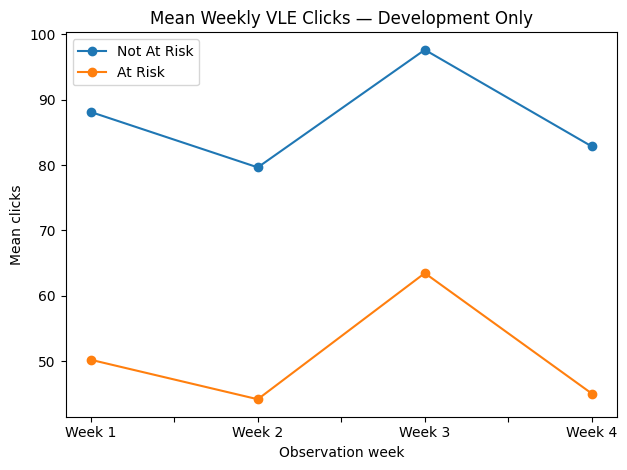

In [8]:
weekly = ['clicks_week1_28d','clicks_week2_28d','clicks_week3_28d','clicks_week4_28d']
weekly_means = dev.groupby(TARGET)[weekly].mean().T
weekly_means.columns = ['Not At Risk','At Risk']
weekly_means.index = ['Week 1','Week 2','Week 3','Week 4']

display(weekly_means.round(2))
ax = weekly_means.plot(marker='o', title='Mean Weekly VLE Clicks — Development Only')
ax.set_ylabel('Mean clicks')
ax.set_xlabel('Observation week')
plt.tight_layout()
plt.show()


In [9]:
for col in ['gender','age_band','highest_education','imd_band']:
    rates = (dev.groupby(col, dropna=False)[TARGET].agg(['mean','count'])
               .rename(columns={'mean':'at_risk_rate'})
               .sort_values('at_risk_rate', ascending=False))
    print('\n', col)
    display(rates.style.format({'at_risk_rate':'{:.2%}','count':'{:,}'}))



 gender


,at_risk_rate,count
gender,,
M,45.63%,"12,089"
F,42.26%,"9,922"



 age_band


,at_risk_rate,count
age_band,,
0-35,46.01%,"15,292"
35-55,39.96%,"6,559"
55<=,32.50%,160



 highest_education


,at_risk_rate,count
highest_education,,
No Formal quals,59.43%,212
Lower Than A Level,52.23%,"8,705"
A Level or Equivalent,39.64%,"9,599"
HE Qualification,35.70%,"3,258"
Post Graduate Qualification,28.69%,237



 imd_band


,at_risk_rate,count
imd_band,,
0-10%,55.58%,"2,098"
10-20,51.94%,"2,241"
20-30%,50.33%,"2,394"
40-50%,44.84%,"2,130"
50-60%,43.93%,"2,174"
30-40%,43.76%,"2,388"
60-70%,40.18%,"2,021"
70-80%,39.79%,"2,048"
80-90%,37.66%,"1,904"


### EDA interpretation
The EDA is descriptive, not causal. Differences between groups or engagement patterns can help us understand the dataset, but they do **not** prove why a student is at risk.

## 5. Preprocessing

The preprocessing matches the project's leakage-safe design:

- Numeric missing values → median imputation
- Categorical missing values → most-frequent imputation
- Categorical features → one-hot encoding
- Scaling → applied to models that benefit from it (Logistic Regression, Linear SVM, KNN, Gaussian Naive Bayes)
- Tree models → no numeric scaling required

Preprocessing is fitted **inside each cross-validation fold**, so validation data never influences imputation, scaling, or category encoding.

In [10]:
X_dev = dev.drop(columns=DROP_FROM_X).reset_index(drop=True)
y_dev = dev[TARGET].astype(int).reset_index(drop=True)
g_dev = dev[GROUP].reset_index(drop=True)

categorical_cols = X_dev.select_dtypes(include=['object','category']).columns.tolist()
numeric_cols = [c for c in X_dev.columns if c not in categorical_cols]

print('Numeric features:', len(numeric_cols))
print('Categorical features:', len(categorical_cols))
print('Categorical columns:', categorical_cols)


Numeric features: 50
Categorical features: 8
Categorical columns: ['code_module', 'code_presentation', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']


In [11]:
def make_preprocessor(scale_numeric=True, dense=False):
    num_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        num_steps.append(('scaler', StandardScaler()))

    return ColumnTransformer([
        ('num', Pipeline(num_steps), numeric_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=not dense)),
        ]), categorical_cols),
    ], sparse_threshold=0.0 if dense else 0.3)


## 6. Course Classification Models

The notebook explicitly includes the main classification algorithms relevant to this project:

1. **Logistic Regression** — linear probabilistic classifier; official final model family.
2. **Naive Bayes (Gaussian)** — probabilistic baseline with the conditional-independence assumption.
3. **K-Nearest Neighbors (KNN)** — instance-based classifier.
4. **Linear SVM** — maximum-margin linear classifier.
5. **Decision Tree** — rule-based nonlinear classifier.
6. **Random Forest** — ensemble extension built from many decision trees.

The official tuned Logistic/SVM/Random-Forest settings are preserved where applicable. Naive Bayes, KNN, and Decision Tree are supplementary **course-coverage baselines** added after the final model was locked.

In [12]:
MODEL_SPECS = {
    'Logistic Regression': {
        'matrix': 'scaled',
        'factory': lambda: LogisticRegression(C=0.05, class_weight='balanced', solver='liblinear', max_iter=1500, random_state=42),
    },
    'Linear SVM': {
        'matrix': 'scaled',
        'factory': lambda: LinearSVC(C=0.01, class_weight='balanced', dual='auto', tol=1e-3, max_iter=7000, random_state=42),
    },
    'Naive Bayes': {
        'matrix': 'dense',
        'factory': lambda: GaussianNB(),
    },
    'KNN': {
        'matrix': 'scaled',
        'factory': lambda: KNeighborsClassifier(n_neighbors=7, weights='distance', algorithm='brute', n_jobs=-1),
    },
    'Decision Tree': {
        'matrix': 'unscaled',
        'factory': lambda: DecisionTreeClassifier(max_depth=10, min_samples_leaf=12, class_weight='balanced', random_state=42),
    },
    'Random Forest': {
        'matrix': 'unscaled',
        'factory': lambda: RandomForestClassifier(
            n_estimators=80, max_depth=12, min_samples_leaf=4, min_samples_split=8,
            max_features='sqrt', class_weight='balanced_subsample', n_jobs=-1, random_state=42
        ),
    },
}

print('Models:', ', '.join(MODEL_SPECS))


Models: Logistic Regression, Linear SVM, Naive Bayes, KNN, Decision Tree, Random Forest


## 7. Development-Only 5-Fold Group-Aware Cross Validation

All six models are compared on exactly the same five development folds. The grouping variable is `id_student`, preventing the same student from appearing in both training and validation within a fold.

Metrics:
- Accuracy
- Precision
- Recall
- F1
- ROC-AUC
- PR-AUC


In [13]:
def evaluate_course_models():
    metric_names = ['accuracy','precision','recall','f1','roc_auc','pr_auc']
    results = {name: [] for name in MODEL_SPECS}
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=CV_SEED)

    for fold, (tr, va) in enumerate(cv.split(X_dev, y_dev, g_dev), start=1):
        print(f'Fold {fold}/5')
        Xtr, Xva = X_dev.iloc[tr], X_dev.iloc[va]
        ytr, yva = y_dev.iloc[tr], y_dev.iloc[va]

        scaled_prep = make_preprocessor(scale_numeric=True, dense=False)
        unscaled_prep = make_preprocessor(scale_numeric=False, dense=False)
        dense_prep = make_preprocessor(scale_numeric=True, dense=True)

        matrices = {
            'scaled': (scaled_prep.fit_transform(Xtr), scaled_prep.transform(Xva)),
            'unscaled': (unscaled_prep.fit_transform(Xtr), unscaled_prep.transform(Xva)),
            'dense': (dense_prep.fit_transform(Xtr), dense_prep.transform(Xva)),
        }

        for name, spec in MODEL_SPECS.items():
            model = spec['factory']()
            A, B = matrices[spec['matrix']]
            model.fit(A, ytr)
            pred = model.predict(B)
            score = model.decision_function(B) if hasattr(model, 'decision_function') else model.predict_proba(B)[:,1]
            results[name].append([
                accuracy_score(yva, pred),
                precision_score(yva, pred, zero_division=0),
                recall_score(yva, pred, zero_division=0),
                f1_score(yva, pred, zero_division=0),
                roc_auc_score(yva, score),
                average_precision_score(yva, score),
            ])

    rows = []
    for name, values in results.items():
        arr = np.asarray(values, dtype=float)
        row = {'model': name}
        for j, metric in enumerate(metric_names):
            row[f'{metric}_mean'] = arr[:,j].mean()
            row[f'{metric}_std'] = arr[:,j].std(ddof=1)
        rows.append(row)

    return pd.DataFrame(rows).sort_values(['f1_mean','recall_mean','roc_auc_mean'], ascending=False).reset_index(drop=True)

start = time.time()
course_cv = evaluate_course_models()
print(f'Finished in {time.time()-start:.1f} seconds')
course_cv.to_csv(COURSE_REPORT_DIR / 'course_model_cv_comparison.csv', index=False)
display(course_cv.style.format({c:'{:.4f}' for c in course_cv.columns if c != 'model'}))


Fold 1/5


Fold 2/5


Fold 3/5


Fold 4/5


Fold 5/5


Finished in 13.4 seconds


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
0,Logistic Regression,0.7147,0.0064,0.6834,0.0053,0.6580,0.0171,0.6704,0.0104,0.7850,0.0091,0.7633,0.0121
1,Linear SVM,0.7147,0.0058,0.6872,0.0046,0.6482,0.0175,0.6670,0.0102,0.7851,0.0090,0.7629,0.0120
2,Random Forest,0.7132,0.0061,0.7008,0.0088,0.6105,0.0119,0.6525,0.0083,0.7772,0.0094,0.7575,0.0112
3,Naive Bayes,0.6040,0.0075,0.5337,0.0059,0.8099,0.0059,0.6434,0.0051,0.7195,0.0093,0.6848,0.0122
4,Decision Tree,0.6872,0.0095,0.6562,0.0179,0.6132,0.0212,0.6336,0.0093,0.7381,0.0085,0.7038,0.0097
5,KNN,0.6894,0.0050,0.6751,0.0063,0.5702,0.0128,0.6182,0.0085,0.7356,0.0073,0.7076,0.0104


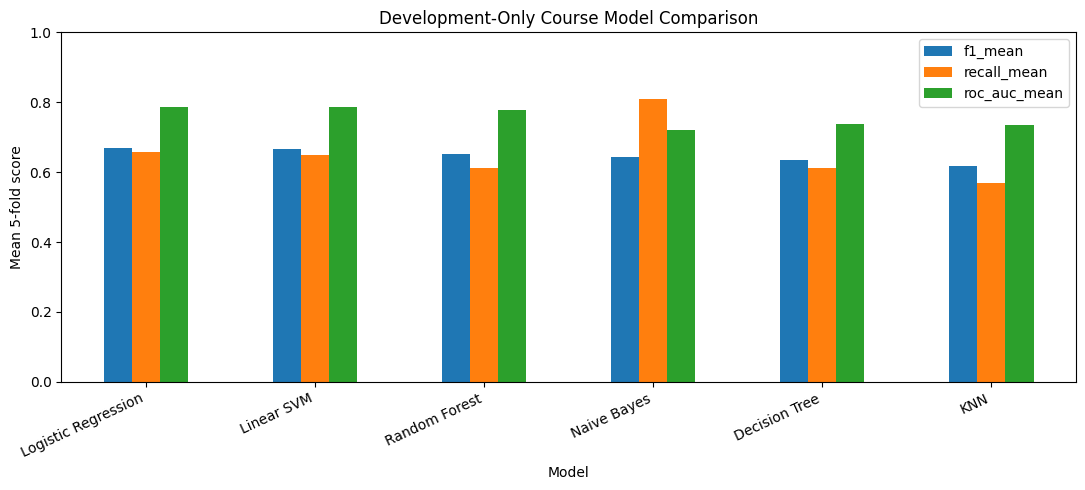

In [14]:
plot_df = course_cv.set_index('model')[['f1_mean','recall_mean','roc_auc_mean']]
ax = plot_df.plot(kind='bar', figsize=(11,5), title='Development-Only Course Model Comparison')
ax.set_ylim(0, 1)
ax.set_ylabel('Mean 5-fold score')
ax.set_xlabel('Model')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


### Interpretation of the course-model comparison

This table is **not a second final-holdout model selection exercise**. It exists to demonstrate the algorithms covered in the course under a rigorous development-only comparison.

The project's official selection rule remains the previously locked tuning process. The extra Naive Bayes, KNN, and Decision Tree rows are educational baselines and do not alter the frozen final outputs.

## 8. Official Tuned Model Selection

The hardened project tuned the primary candidate families on development-only 5-fold `StratifiedGroupKFold` and selected the model with the highest mean F1 (recall then ROC-AUC as tie-breakers).

In [15]:
selection = json.loads((PROJECT_ROOT / 'reports' / 'tuning' / 'model_selection.json').read_text(encoding='utf-8'))
tuned_cv = pd.read_csv(PROJECT_ROOT / 'reports' / 'tuning' / 'tuned_model_cv_summary.csv')

display(tuned_cv[['model','f1_mean','recall_mean','roc_auc_mean','pr_auc_mean','selection_rank']]
        .style.format({'f1_mean':'{:.4f}','recall_mean':'{:.4f}','roc_auc_mean':'{:.4f}','pr_auc_mean':'{:.4f}'}))

print('Selected model:', selection['selected_model'])
print('Selected parameters:', selection['selected_params'])
print('Locked holdout target used during tuning:', not selection['final_holdout_target_not_used_during_tuning'])


,model,f1_mean,recall_mean,roc_auc_mean,pr_auc_mean,selection_rank
0,logistic_regression,0.6704,0.6580,0.7850,0.7633,1
1,linear_svm,0.6670,0.6482,0.7851,0.7629,2
2,random_forest,0.6525,0.6105,0.7772,0.7575,3


Selected model: logistic_regression
Selected parameters: {'C': 0.05, 'class_weight': 'balanced'}
Locked holdout target used during tuning: False


## 9. Locked Evaluation Results — Official Final Model

Only after model selection, calibration, and threshold design were fixed do we report the packaged locked evaluation results below.

**Important limitation:** this is a locked evaluation holdout, not a pristine external test cohort, because diagnostics from this holdout were viewed during earlier project iteration. External/future-cohort validation remains recommended.

In [16]:
metrics_all = json.loads((PROJECT_ROOT / 'reports' / 'final' / 'final_test_metrics.json').read_text(encoding='utf-8'))
metrics = metrics_all['tuned_threshold_metrics']
metric_map = {
    'Accuracy': metrics['accuracy'],
    'Precision': metrics['precision'],
    'Recall': metrics['recall'],
    'F1': metrics['f1'],
    'ROC-AUC': metrics['roc_auc'],
    'PR-AUC': metrics['pr_auc'],
    'Brier': metrics['brier'],
    'ECE (10 quantile)': metrics['ece_10_quantile'],
}
metric_table = pd.DataFrame({'Metric': list(metric_map), 'Value': list(metric_map.values())})
display(metric_table.style.format({'Value':'{:.4f}'}))

cm = np.array([[metrics['tn'], metrics['fp']], [metrics['fn'], metrics['tp']]])
cm_df = pd.DataFrame(cm, index=['Actual Not At Risk','Actual At Risk'], columns=['Predicted Not At Risk','Predicted At Risk'])
display(cm_df)


,Metric,Value
0,Accuracy,0.6871
1,Precision,0.6059
2,Recall,0.8320
3,F1,0.7011
4,ROC-AUC,0.7977
5,PR-AUC,0.7770
6,Brier,0.1791
7,ECE (10 quantile),0.0148


,Predicted Not At Risk,Predicted At Risk
Actual Not At Risk,1762,1314
Actual At Risk,408,2020


### Why recall matters here
The system is an **early-warning** tool. Missing a genuinely at-risk student can mean losing an opportunity for support. Therefore recall is important, while precision is also monitored to understand staff workload from false positives.

## 10. Risk Probability and Risk Levels

In [17]:
thresholds = json.loads((PROJECT_ROOT / 'reports' / 'final' / 'risk_thresholds.json').read_text(encoding='utf-8'))
print(json.dumps(thresholds, indent=2))

risk_dist = pd.DataFrame(json.loads((PROJECT_ROOT / 'reports' / 'final' / 'risk_level_distribution.json').read_text(encoding='utf-8')))
display(risk_dist.style.format({'actual_risk_rate':'{:.2%}','mean_probability':'{:.4f}','n':'{:,}'}))


{
  "low_risk_upper_threshold": 0.2509141267833343,
  "high_risk_lower_threshold": 0.3197141943804115,
  "medium_range": "[0.250914, 0.319714)",
  "threshold_method": "Low boundary is the highest OOF-calibrated probability threshold maintaining >=90% recall. High/decision boundary maximizes development OOF F1.",
  "oof_f1_at_high_threshold": 0.6903030303030302
}


,risk_level,n,actual_risk_rate,mean_probability
0,High,"3,334",60.59%,0.5946
1,Low,"1,491",15.96%,0.1697
2,Medium,679,25.04%,0.2849


## 11. Explainability — SHAP and Logistic Coefficients

- **Global SHAP**: which transformed features matter most across the model.
- **Local SHAP**: which features push a selected enrollment's risk score up or down.
- **Logistic coefficients**: direction of model association, **not causality**.

The dashboard computes a local explanation on demand for any selected enrollment using the frozen final model.

,feature,source_feature,mean_abs_shap,interpretation
0,num__assessment_weight_completed_28d,assessment_weight_completed_28d,0.361823,Global importance magnitude only; larger value...
1,num__weighted_assessment_score_28d,weighted_assessment_score_28d,0.341927,Global importance magnitude only; larger value...
2,num__active_days_28d,active_days_28d,0.249228,Global importance magnitude only; larger value...
3,num__assessment_weight_due_28d,assessment_weight_due_28d,0.231269,Global importance magnitude only; larger value...
4,num__unique_sites_28d,unique_sites_28d,0.222789,Global importance magnitude only; larger value...
5,num__assessment_completion_rate_28d,assessment_completion_rate_28d,0.194844,Global importance magnitude only; larger value...
6,cat__code_module_FFF,code_module,0.193078,Global importance magnitude only; larger value...
7,num__late_submissions_28d,late_submissions_28d,0.192357,Global importance magnitude only; larger value...
8,cat__highest_education_Lower Than A Level,highest_education,0.181753,Global importance magnitude only; larger value...
9,num__assessments_submitted_28d,assessments_submitted_28d,0.172111,Global importance magnitude only; larger value...


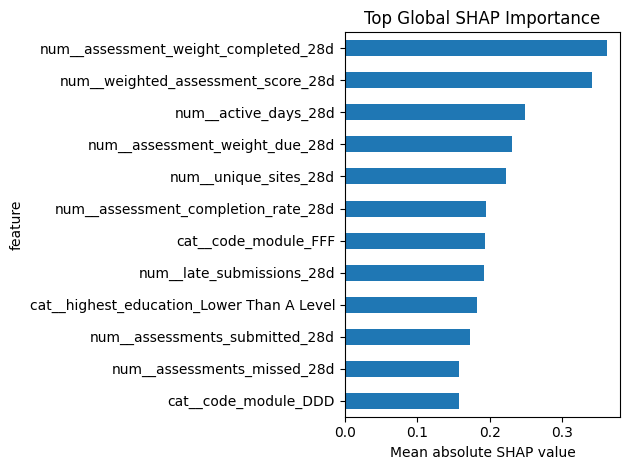

In [18]:
global_shap = pd.read_csv(PROJECT_ROOT / 'reports' / 'final' / 'shap_global_importance.csv').head(12)
display(global_shap)

value_col = 'mean_abs_shap' if 'mean_abs_shap' in global_shap.columns else global_shap.select_dtypes(include='number').columns[-1]
name_col = [c for c in global_shap.columns if c != value_col][0]
ax = global_shap.sort_values(value_col).plot(kind='barh', x=name_col, y=value_col, legend=False, title='Top Global SHAP Importance')
ax.set_xlabel('Mean absolute SHAP value')
plt.tight_layout()
plt.show()


## 12. Rule-Based Recommendations

The prediction itself is not a punishment or an automatic academic decision. The intended workflow is:

**Day-28 data → risk probability → risk level → explanation → support recommendation → human review/intervention**.

Recommendations are deterministic support rules based on observed early-warning signals. They are not generated by the target label.

In [19]:
rec_cfg = json.loads((PROJECT_ROOT / 'reports' / 'final' / 'recommendation_config.json').read_text(encoding='utf-8'))
print(json.dumps(rec_cfg, indent=2)[:5000])


{
  "assessment_score_low": 65.0,
  "completion_rate_low": 1.0,
  "days_since_activity_high": 5.0,
  "active_days_last7d_low": 1.0,
  "clicks_last7d_low": 2.0,
  "weekly_click_slope_low": -9.8
}


## 13. ANN / Deep-Learning Extension

An ANN/MLP extension is included as **additional course material**, evaluated only on development data. It is not the official final model and does not access locked evaluation labels.

In [20]:
ann = json.loads((PROJECT_ROOT / 'reports' / 'ann_extension' / 'ann_extension_metrics.json').read_text(encoding='utf-8'))
ann_summary = pd.DataFrame({
    'Metric': ['Accuracy','Precision','Recall','F1','ROC-AUC','PR-AUC'],
    'Mean': [ann['accuracy_mean'],ann['precision_mean'],ann['recall_mean'],ann['f1_mean'],ann['roc_auc_mean'],ann['pr_auc_mean']],
    'Std': [ann['accuracy_std'],ann['precision_std'],ann['recall_std'],ann['f1_std'],ann['roc_auc_std'],ann['pr_auc_std']],
})
display(ann_summary.style.format({'Mean':'{:.4f}','Std':'{:.4f}'}))
print(ann['note'])


,Metric,Mean,Std
0,Accuracy,0.7004,0.0030
1,Precision,0.6857,0.0111
2,Recall,0.5934,0.0311
3,F1,0.6357,0.0140
4,ROC-AUC,0.7597,0.0053
5,PR-AUC,0.7388,0.0052


Exploratory sklearn MLP extension evaluated only on development data with 3-fold student-group-aware CV; it is not a primary-model candidate and does not access locked-holdout labels. The optional Keras script demonstrates course-aligned BatchNorm/Dropout/EarlyStopping separately.


## 14. Course Coverage Map

| Course topic | Status in this project | Where |
|---|---|---|
| Define classification target | ✅ | Sections 1–2 |
| Leakage removal | ✅ | Section 2 |
| Missing-value imputation | ✅ | Section 5 |
| One-hot encoding | ✅ | Section 5 |
| Scaling | ✅ | Section 5 |
| Group-aware train/evaluation split | ✅ | Section 3 |
| Logistic Regression | ✅ | Sections 6–8 |
| Naive Bayes | ✅ | Sections 6–7 |
| KNN | ✅ | Sections 6–7 |
| SVM | ✅ | Sections 6–8 |
| Decision Tree | ✅ | Sections 6–7 |
| Random Forest | ✅ extension | Sections 6–8 |
| Accuracy / Precision / Recall / F1 | ✅ | Sections 7–9 |
| ROC-AUC | ✅ | Sections 7–9 |
| Confusion Matrix | ✅ | Section 9 |
| 5-Fold Cross Validation | ✅ | Section 7 |
| Hyperparameter tuning | ✅ | Section 8 / project source |
| Select best model | ✅ | Section 8 |
| Risk probability / level | ✅ | Sections 9–10 |
| ANN / activation / optimization concepts | ✅ extension | Section 13 + optional Keras source |
| SHAP / top risk factors | ✅ extension | Section 11 |
| Recommendation engine | ✅ extension | Section 12 |
| Fairness audit | ✅ extension | packaged reports/dashboard |
| Regression / MSE | Not applicable to the binary target | — |
| Clustering / K-Means++ / DBSCAN / GMM | Not applicable to the supervised target | — |
| PCA | Not required for the final tabular pipeline | — |
| CNN | Not appropriate for this tabular dataset | — |
| Reinforcement Learning | Not required for prediction task | — |


## 15. Final Project Story

1. Observe each enrollment only through **Day 28**.
2. Build leakage-safe engagement and early-assessment features.
3. Split by **student identity**, not random rows.
4. Run development-only EDA and model comparison.
5. Tune primary candidate models with group-aware CV.
6. Lock Logistic Regression (`C=0.05`, `class_weight='balanced'`).
7. Report locked evaluation performance.
8. Convert probability to Low / Medium / High risk.
9. Explain predictions with SHAP.
10. Present support recommendations to a human academic advisor through the web dashboard.

### One-sentence viva answer
> We built a Day-28 early-warning classification system that predicts academic risk from early student activity, explains the prediction, and supports timely human intervention.


## 16. Reproducibility

From the project root:

```bash
python src/validate_project.py
python demo/app.py
```

To rerun this notebook, open it in VS Code/Jupyter and **Run All**. The course comparison writes only to `reports/course_models/`; it does not overwrite the hardened final model artifacts.